In [64]:
import sys
print(sys.executable)

/Users/claramal/miniconda3/envs/analysis_env/bin/python


In [32]:
import sys, os, re, importlib
import baltic as bt
import pandas as pd
import numpy as np
from scipy.special import binom
from collections import defaultdict, Counter
from plotnine import *
from geopy.distance import geodesic
from geopy.distance import great_circle
from datetime import datetime, timedelta
from scipy import stats
import arviz as az

In [33]:
def decimal_year_to_datetime(decimal_year):
    year = int(decimal_year)
    remainder = decimal_year - year

    start = datetime(year, 1, 1)
    end = datetime(year + 1, 1, 1)

    return start + timedelta(seconds=remainder * (end - start).total_seconds())

In [34]:
# This script needs to accomplish three things
# One: calculate and plot the WDC and spatial wavefront across the posterior distribution
# Two: calculate and plot the WDC and spatial wavefront from the MCC tree
# Three: plot these stats from SERAPHIM output if you manage to run it

In [35]:
continent_dict = {"north-canada":"north-america",
                  "northeast-us":"north-america",
                  "northwest-us":"north-america",
                  "asia":"asia",
                  "east-canada":"north-america",
                  "europe":"europe",
                  "ancestor":"ancestor"
                 }

continent_colors = {"asia":"#b09a6e",
                    "north-america":"#95b8d1",
                    "europe":"#ffaaaa"}

# host_colors = {"seab":"#6aa1f4", 
#                "bdpr": "#f69ba6", 
#                "gds": "#6a994e", 
#                "mammal": "#a874d2", 
#                "scav": "#923e4d", 
#                "grdbd": "#e9c46a"
#               }

host_colors = {"bird-of-prey":"#C43110", # red-maroon
                     "duck":"#679C48", # green 
                     "goose-swan": "#DBB730", # yellow
                     "shorebird":"#68A0A6", # blue
                     "songbird-etc":"#D9A7B0", # pink
                     "ground-bird":"#E08907", # orange
                     "diving-bird":"#503A63", # deep purple
                     "other":"#A0A0A3" # grey
                    }

host_labels = {"bird-of-prey":"Birds of Prey", # red-maroon
                     "duck":"Ducks", # green 
                     "goose-swan": "Geese and Swans", # yellow
                     "shorebird":"Shorebirds and Seabirds", # blue
                     "songbird-etc":"Songbirds, Corvids, etc.", # pink
                     "ground-bird":"Ground Birds", # orange
                     "diving-bird":"Diving Birds", # deep purple
                     "other":"Other" # grey
                    }

In [7]:
# Function: generate a metadata dataframe from an MCC tree

def mcc_to_metadata(treeFile):

    # Read in the tree and print some stats
    tree = bt.loadNexus(treeFile)
    tree.treeStats()

    # Give each node and tip a label
    label_count = 0
    for k in tree.Objects:
        k.label = label_count
        label_count += 1

    # Make the metadata
    metadata = []
    
    for obj in tree.Objects:
        children = []
    
        if obj.is_node():
            children.extend(obj.children) # Use .extend instead of .append, the former makes a flat list while the latter appends a list into the list
            node1 = obj.label
            startYear = obj.absoluteTime
            length = obj.traits["length"]
            startLatGrp = obj.traits["region"]
            startOrder = obj.traits["host"] # ncbibvbrc_hostgroup # host
            startLat = obj.traits["location1"]
            startLong = obj.traits["location2"]
            
            for child in children:
                node2 = child.label
                endYear = child.absoluteTime
                endLatGrp = child.traits["region"]
                endOrder = child.traits["host"] # ncbibvbrc_hostgroup # host
                endLat = child.traits["location1"]
                endLong = child.traits["location2"]
                tip = getattr(child, 'name', pd.NA)
                
                metadata.append({
                    "node1": node1,
                    "node2": node2,
                    "length": length,
                    "startYear": startYear,
                    "endYear": endYear,
                    "startLat": startLat,
                    "startLon": startLong,
                    "endLat": endLat,
                    "endLon": endLong,
                    "startRegion": startLatGrp,
                    "endRegion": endLatGrp,
                    "startHost": startOrder,
                    "endHost": endOrder,
                    "tipLabel": tip
                    })                     
        else:
            pass

    df = pd.DataFrame(metadata)

    # Now, calculate distance per branch, time, and distance from origin
    df["dist_branch"] = df.apply(lambda row: great_circle((row["startLat"], row["startLon"]),(row["endLat"], row["endLon"])).kilometers,axis=1)
    df["time"] = df["endYear"] - df["startYear"]
    origin = df[df["node1"] == 0].iloc[0]
    df["dist_origin"] = df.apply(lambda row: great_circle((origin["startLat"], origin["startLon"]),(row["endLat"], row["endLon"])).kilometers,axis=1) # NOT SURE IF THIS IS CALC RIGHT

    return(df)

In [8]:
# mcc_tree = "../../H5N5-seabird-phylo/SERAPHIM/A6_concat-genome_traits_2026-03-10_MCC.tree"
# mcc_tree = "../BEAST/continuous_phylogeography/results/2026-03-25_main-intro_equal-time-host-3000_ha_traits/main-intro_equal-time-host-3000_ha_traits_MCC.tree"
# mcc_tree = "../../SERAPHIM_tests/main-intro_liveharvest_ha_traits_MCC.tree"
mcc_tree = "../../H5N5-seabird-phylo/BEAST/cont-phyl_dta/results/2026-07-09_A6_concat_genome_traits/A6_concat-gen_traits_2026-07-09_MCC.tree"


mcc_metadata = mcc_to_metadata(mcc_tree)


Tree height: 5.417775
Tree length: 112.448746
strictly bifurcating tree

Numbers of objects in tree: 723 (361 nodes and 362 leaves)



In [6]:
# Function: To extract the lines with taxa information from the .trees file to add to .temp.tree
def get_taxa_lines(tree_path):    
    
    # write out a temp tree file
    temp_tree = tree_path.replace(".trees",".temp.tree")
    with open(temp_tree, "w") as outfile: 
        outfile.write("")

    lines_to_write = ""
    with open(tree_path) as infile:
        for line in infile: ## iterate through each line
            if 'state' not in line.lower(): #going to grab all the interesting stuff in the .trees file prior to the newick tree strings
                lines_to_write = lines_to_write + line

    return(lines_to_write)

In [7]:
# Function: To generate a metadata dataframe from each one in a distribution
def distribution_to_metadata(tree, dictionary):
    
    # Add a label for each node and tip
    label_count = 0
    for k in tree.Objects:
        k.label = label_count
        label_count += 1

    # Make the metadata
    metadata = []
    
    # For each tree, turn the tree into a df
    for obj in tree.Objects:
        children = []

        if obj.is_node():
            
            children.extend(obj.children) # Use .extend instead of .append, the former makes a flat list while the latter appends a list into the list
            node1 = obj.label
            startYear = obj.absoluteTime
            # startYear = MRSD - obj.traits.get("height")
            length = obj.length
            startLat = obj.traits.get("location")[0] # This works for the velocity_distribution function below but not for an MCC tree
            startLong = obj.traits.get("location")[1]
            startContinent = dictionary[obj.traits.get("region")]
            startHost = obj.traits.get("host") #ncbibvbrc_hostgroup
            # startStatus = obj.traits.get("domesticstatus")
            
            for child in children:
                node2 = child.label
                endYear = child.absoluteTime
                # endYear = MRSD - child.traits.get("height")
                endLat = child.traits.get("location")[0]
                endLong = child.traits.get("location")[1]
                endHost = child.traits.get("host") #ncbibvbrc_hostgroup
                endContinent = dictionary[child.traits.get("region")]
                # endStatus = child.traits.get("domesticstatus")
                tip = getattr(child, 'name', pd.NA)
            
                metadata.append({
                    "node1": node1,
                    "node2": node2,
                    "length": length,
                    "startYear": startYear,
                    "endYear": endYear,
                    "startLat": startLat,
                    "startLon": startLong,
                    "endLat": endLat,
                    "endLon": endLong,
                    "startContinent": startContinent,
                    "endContinent": endContinent,
                    "startHost":startHost,
                    "endHost": endHost,
                    # "startStatus": startStatus,
                    # "endStatus": endStatus,
                    "tipLabel": tip
                    }) 
                
        else:
            pass

    df = pd.DataFrame(metadata)

    # There are a couple of trees in of of my distributions where the start or end latitude is greater than 90
    # I am not sure whether to set it to a maximum or remove those trees
    # df.loc[df["startLat"] > 90, "startLat"] = 90
    # df.loc[df["endLat"] > 90, "endLat"] = 90

    # I have decided to get rid of it
    for idx, row in df.iterrows():
        startLat = row["startLat"]
        endLat = row["endLat"]
        if startLat > 90:
            return
        elif endLat > 90:
            return
        else: 
            pass

    # print(df["tipLabel"].loc[df["tipLabel"].str.contains("A/Washington", na=False)])
    # print(df["endYear"].loc[df["endYear"] == max(df["endYear"])])

    # Now, calculate distance per branch, time, and distance from origin
    df["dist_branch"] = df.apply(lambda row: great_circle((row["startLat"], row["startLon"]),(row["endLat"], row["endLon"])).kilometers,axis=1)
    df["time"] = df["endYear"] - df["startYear"]
    origin = df[df["node1"] == 0].iloc[0]
    df["dist_origin"] = df.apply(lambda row: great_circle((origin["startLat"], origin["startLon"]),(row["endLat"], row["endLon"])).kilometers,axis=1)

    return(df)

In [8]:
# Function: Generate a dictionary of metadata dataframes from a distribution

def distribution_dict(tree_path, numtrees, burnin_percent, temp_tree, dictionary):

    treeCounter = 0
    burnin = int(numtrees * burnin_percent)
    metadata_dict = {}

    # trees = bt.loadNexus(tree_path)
    with open(tree_path) as infile:
        for line in infile:

            # write an empty tree to read file; this will get filled in as a new nexus file for each tree in the posterior
            with open(temp_tree, "w") as outfile:
                outfile.write("")

            if 'tree STATE_' in line:
                treeCounter += 1
                if treeCounter > burnin:
                # if treeCounter < 5:
                    # metadata_dict[f"tree{treeCounter}"] = {} # I don't think I actually need this line here
                    with open(temp_tree, "a") as outfile:
                        outfile.write(lines_to_write)
                        outfile.write(line)
                    tree = bt.loadNexus(temp_tree)

                    metadata = distribution_to_metadata(tree, dictionary)
                    
                    if metadata is None: # Trying to avoid situations where I skip a tree for some reason and it adds None to the dictionary
                        pass
                    else:
                        metadata_dict[f"tree{treeCounter}"] = metadata

    return(metadata_dict)

In [52]:
# tree_path = "../../H5N5-seabird-phylo/SERAPHIM/A6_concat-genome_traits_2026-03-10_901combined.trees"
# tree_path = "../../SERAPHIM_tests/main-intro_liveharvest_ha_traits_8combined.trees"
# tree_path = "../../H5-genotypes/SERAPHIM/h5_B3.2_exponential_traits/B3.2_ha_exponential_traits_2026-04-06_901combined.trees"
# tree_path = "../../H5-genotypes/SERAPHIM/h5_D1.1_exponential_traits/D1.1_ha_exponential_traits_2026-04-06_901combined.trees"
# tree_path = "../../H5-genotypes/SERAPHIM/h5_A1_A2_exponential_traits/A1_A2_ha_exponential_traits_2026-04-06_901combined.trees"
# tree_path = "../../H5-genotypes/SERAPHIM/h5_B3.6_exponential_traits/B3.6_ha_exponential_traits_2026-04-06_901combined.trees"
# tree_path = "../../H5-genotypes/SERAPHIM/h5_A3_exponential_traits/A3_ha_exponential_traits_2026-04-06_901combined.trees"
# tree_path = "../../H5-genotypes/SERAPHIM/h5_C2.1_exponential_traits/C2.1_ha_exponential_traits_2026-04-06_901combined.trees"
# tree_path = "../../H5N5-seabird-phylo/BEAST/cont-phyl_dta/results/2026-07-09_A6_concat_genome_traits/A6_concat-gen_traits_2026-07-09_901combined.trees"
tree_path = "../../H5N5-seabird-phylo/BEAST/cont-phyl_dta/results/2026-08-04_A6_concat_genome_traits_TEST/A6_concat-gen_traits_2026-08-04_884combined.trees"

temp_tree = tree_path.replace(".trees",".tempcomm.tree")
lines_to_write = get_taxa_lines(tree_path)

In [53]:
# MRSD = 2025.8575342465754
MRSD = 2026.0520547945205

# metadata_dict = distribution_dict(tree_path, 901, 0.1, temp_tree, continent_dict)
# metadata_dict = distribution_dict(tree_path, 8, 0, temp_tree, continent_dict)
# metadata_dict = distribution_dict(tree_path, 901, 0.1, temp_tree)
metadata_dict = distribution_dict(tree_path, 884, 0.0, temp_tree, continent_dict)

In [54]:
# Function: calculates the average weighted diffusion coefficient from either the posterior distirbution or an MCC tree
def calculate_avg_wdc(metadata):

    if isinstance(metadata, dict): # If you are calculating from a dictionary of dataframes
        posterior_wdc = {}
        df_count = 1
        # print(len(metadata.values()))
        for df in metadata.values():
            # print(type(df))
            posterior_wdc[df_count] = {}

            # Measure [average] WDC by continent
            for i in set(df["startContinent"]): 
                df_continent = df.loc[(df["startContinent"] == i) & (df["endContinent"] == i)]
                # print(len(df_continent), set(df_continent["startContinent"]), set(df_continent["endContinent"]))

                wdc_continent = (df_continent["dist_branch"] ** 2).sum() / (4 * (df_continent["time"] * 365)).sum() # Calculate time in days, not years
                    
                posterior_wdc[df_count][i] = wdc_continent # Save the WDC of each continent to a dictionary
            
            df_count += 1 # Increase the dataframe count and move to the next datafrome in the distribution

        posterior_wdc_df = pd.DataFrame(posterior_wdc).fillna(0)
        posterior_wdc_df_long = (posterior_wdc_df.reset_index().rename(columns={'index': 'continent'}).melt(id_vars='continent',var_name='tree',value_name='wdc'))
    
        return(posterior_wdc_df_long)

    elif isinstance(metadata, pd.DataFrame): # if you are calculating from just one dataframe
        mcc_wdc = {}

        for i in set(metadata["startHost"]): # Measure WDC by host

            mcc_wdc[i] = {}
            
            metadata_host = metadata.loc[(metadata["startHost"] == i) & (metadata["endHost"] == i)]

            wdc_host = (metadata_host["dist_branch"] ** 2).sum() / (4 * (metadata_host["time"] * 365)).sum() # Calculate time in days, not years

            mcc_wdc[i] = wdc_host

        mcc_wdc_df = pd.DataFrame.from_dict(mcc_wdc, orient="index", columns=["wdc"])
        
        return(mcc_wdc_df)

    else:
        print("Metadata of unknown type")

In [82]:
# Function: calculates the average weighted diffusion coefficient from either the posterior distirbution or an MCC tree
def calculate_avg_wdc(metadata):

    if isinstance(metadata, dict): # If you are calculating from a dictionary of dataframes
        posterior_wdc = {}
        df_count = 1
        
        for df in metadata.values():
            
            posterior_wdc[df_count] = {}

            wdc = (df["dist_branch"] ** 2).sum() / (4 * df["time"]).sum() # Calculate time in years

            posterior_wdc[df_count] = wdc # Save the WDC of each continent to a dictionary
            
            df_count += 1 # Increase the dataframe count and move to the next datafrome in the distribution

        posterior_wdc_df = pd.DataFrame.from_dict(posterior_wdc, orient = "index")
        posterior_wdc_df.columns = ["wdc"]   
        return(posterior_wdc_df)

    elif isinstance(metadata, pd.DataFrame): # if you are calculating from just one dataframe

        mcc_wdc = (metadata["dist_branch"] ** 2).sum() / (4 * metadata["time"] ).sum() # Calculate time in years
        
        return(mcc_wdc)

    else:
        print("Metadata of unknown type")

In [55]:
wdc_distrib = calculate_avg_wdc(metadata_dict)
# wdc_mcc = calculate_avg_wdc(mcc_metadata)

In [56]:
# HDI for distribution

hdi_hosts = wdc_distrib.groupby("continent")["wdc"].apply(lambda col: az.hdi(col.values, hdi_prob=0.95))

wdc_distrib_error = hdi_hosts.apply(pd.Series)
wdc_distrib_error.columns = ["lower", "upper"]

wdc_distrib_error["median"] = wdc_distrib.groupby("continent")["wdc"].median()
wdc_distrib_error["mean"] = wdc_distrib.groupby("continent")["wdc"].mean()

wdc_distrib_error = wdc_distrib_error.reset_index()

In [57]:
# print(wdc_mcc)

# hdi = wdc_distrib.apply(lambda col: az.hdi(col.values, hdi_prob=0.95))
hdi = az.hdi(wdc_distrib["wdc"], hdi_prob = 0.95)
median = wdc_distrib["wdc"].median()
mean = wdc_distrib["wdc"].mean()
print(hdi, "\n", median, mean)

<xarray.Dataset> Size: 64B
Dimensions:  (hdi: 2)
Coordinates:
  * hdi      (hdi) <U6 48B 'lower' 'higher'
Data variables:
    x        (hdi) float64 16B 169.2 1.694e+04
Attributes:
    created_at:     2026-08-14T14:51:49.978951+00:00
    arviz_version:  0.23.4 
 1660.956960579841 3941.2259788748033


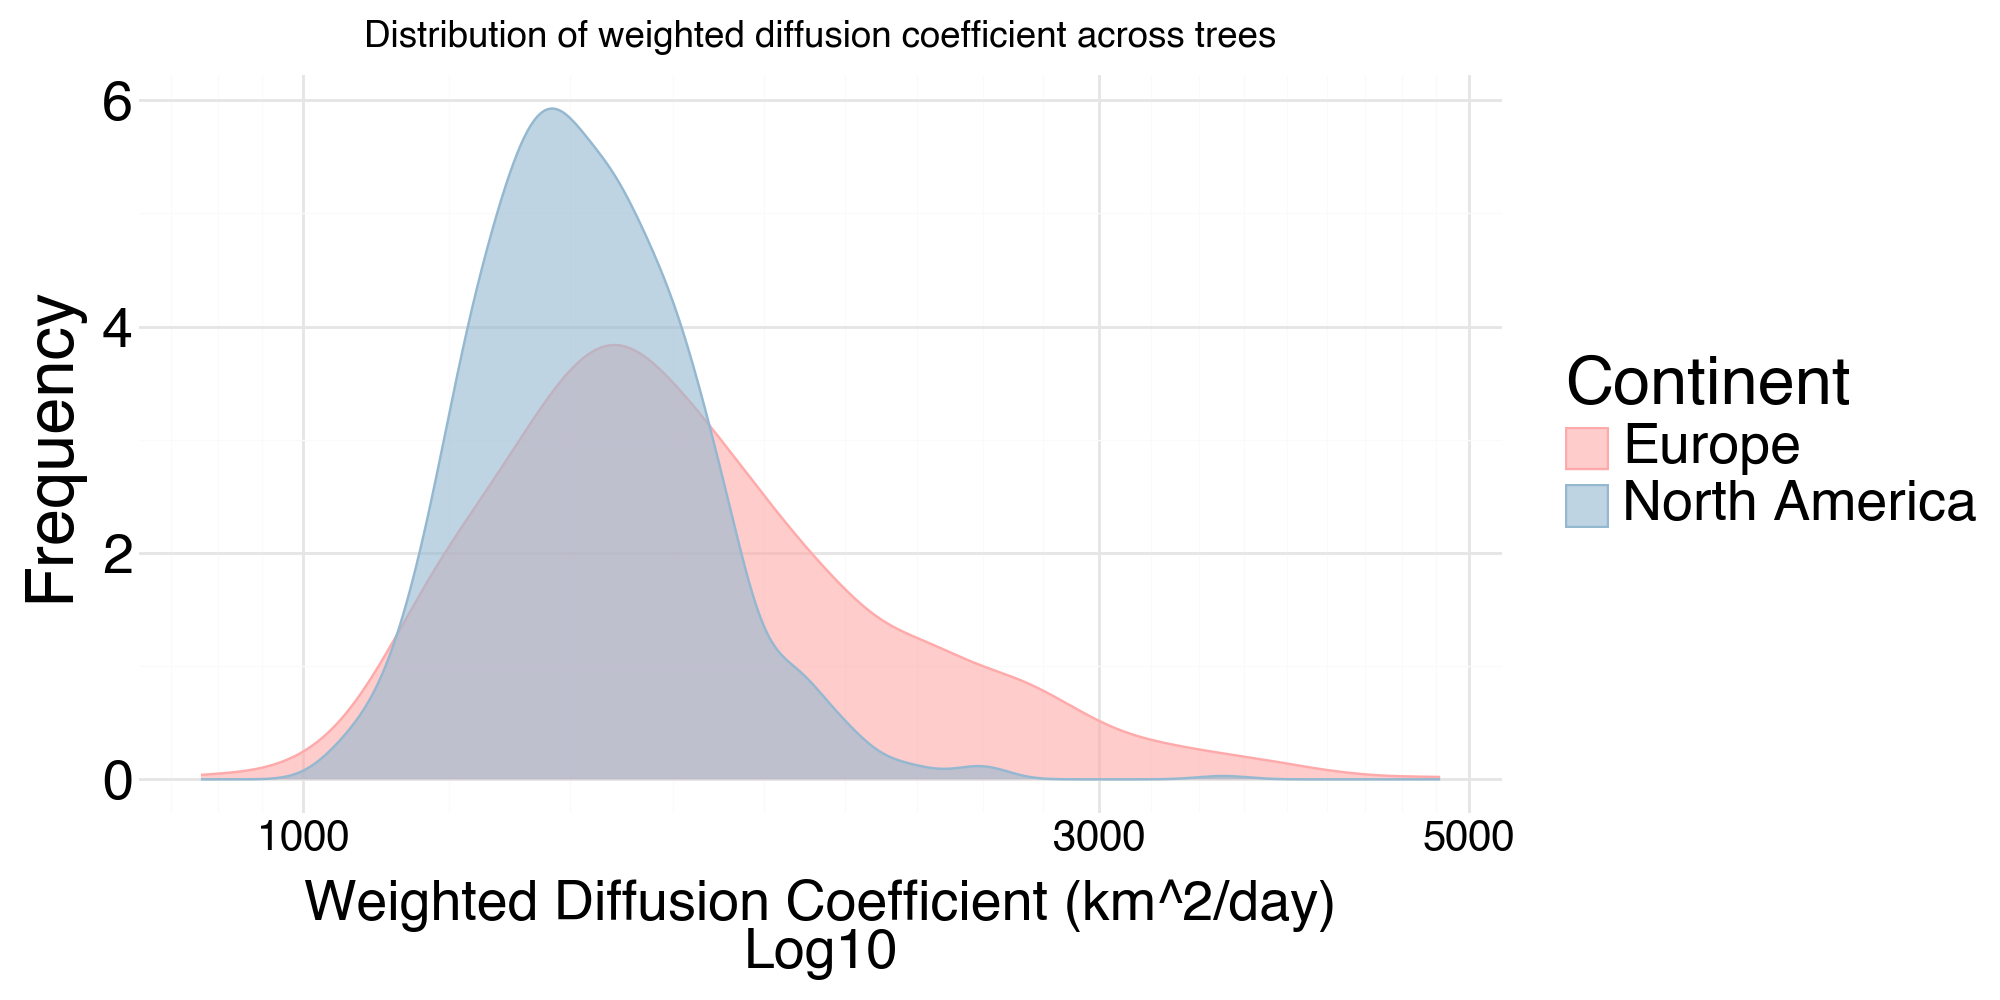

In [64]:
wdc_plt = (
    ggplot(wdc_distrib[~(wdc_distrib["continent"] == "asia")], aes(x='wdc', color="continent", fill="continent"))
    + geom_density(alpha=0.6)
    # + facet_wrap("continent")
    + labs(title='Distribution of weighted diffusion coefficient across trees',x='Weighted Diffusion Coefficient (km^2/day)\nLog10',y='Frequency', fill = "Continent", color = "Continent")
    + scale_fill_manual(values = continent_colors, labels = {"europe":"Europe", "asia":"Asia", "north-america":"North America"})
    + scale_color_manual(values = continent_colors, labels = {"europe":"Europe", "asia":"Asia", "north-america":"North America"})
    # + geom_vline(xintercept = hdi_results["asia"], color = "#b09a6e", linetype = "dashed")
    # + geom_vline(xintercept = hdi_results["europe"], color = "#ffaaaa", linetype = "dashed")
    # + geom_vline(xintercept = hdi_results["north-america"], color = "#95b8d1", linetype = "dashed")
    + scale_x_log10()
    + theme_minimal()
    + theme(figure_size = (10,5), legend_title = element_text(size = 24), legend_text=element_text(size=20), 
            axis_title_x = element_text(size = 20), axis_text_x = element_text(size = 15, color = "black"),
            axis_title_y = element_text(size = 24), axis_text_y = element_text(size = 20, color = "black"))
)

# wdc_plt = (
#     ggplot(wdc_df, aes(x = wdc_df.index, y='wdc', fill=wdc_df.index))
#     + geom_col()
#     # + facet_wrap("continent")
#     + labs(title='Weighted diffusion coefficient per host group',x='Host Group',y='Weighted Diffusion Coefficient (all time)')
#     + scale_fill_manual(host_colors)
#     + theme_minimal()
#     + theme(figure_size = (10,5), axis_text_x=element_text(rotation=45))
# )

# wdc_per_host_bar = (
#     ggplot()
#     # + geom_col(wdc_mcc, aes(x = wdc_mcc.index, y='wdc', fill=wdc_mcc.index))
#     + geom_errorbar(wdc_distrib_error, aes(x = "host", ymin = "lower", ymax = "upper"), width = 0.1, color = "black")
#     + geom_point(wdc_distrib_error, aes(x = "host", y = "median", color = "host"), size = 4)
#     # + geom_point(wdc_distrib_error, aes(x = "host", y = "mean"), color = "black")
#     + labs(x='Host',y='Weighted Diffusion Coefficient', color = "Host at Starting Node", fill = "Host at Starting Node")
#     + scale_fill_manual(host_colors, labels = host_labels)
#     + scale_color_manual(host_colors, labels = host_labels)
#     + theme_minimal()
#     + theme(figure_size = (10,6), legend_text=element_text(size=24), axis_title_x = element_text(size = 20), 
#             axis_title_y = element_text(size = 20), text=element_text(size=20), axis_text_x = element_text(rotation = 60, size = 13))
# )

# wdc_per_host = (
#     ggplot(wdc_mcc, aes(x = wdc_mcc.index, y='wdc', fill=wdc_mcc.index))
#     + geom_col()
#     # + facet_wrap("continent")
#     + labs(x='Host Group',y='Average Weighted Diffusion Coefficient \n (across all time)')
#     + scale_fill_manual(host_colors, labels = host_labels)
#     + theme_minimal()
#     + theme(figure_size = (10,5), axis_text_x=element_text(rotation=45))
# )

# wdc_per_host.show()
# wdc_per_host_bar.show() 
wdc_plt.show()                      

In [65]:
wdc_plt.save("../../H5N5-seabird-phylo/SERAPHIM/plots/wdc_across_posterior.png", format = "png", dpi = 750)

/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 5 in image.
/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../../H5N5-seabird-phylo/SERAPHIM/plots/wdc_across_posterior.png


In [67]:
def decimal_year_to_datetime(decimal_year):
    year = int(decimal_year)
    remainder = decimal_year - year

    start = datetime(year, 1, 1)
    end = datetime(year + 1, 1, 1)

    return (start + timedelta(seconds=remainder * (end - start).total_seconds())).date()

In [68]:
def extract_month_index(dictionary):

    date_list = []

    for i in dictionary.values():
        i["startYear_datetime"] = i["startYear"].apply(decimal_year_to_datetime) # Turn startYear from a float into a datetime object
        i["endYear_datetime"] = i["endYear"].apply(decimal_year_to_datetime) # Turn endYear from a float into a datetime object
        start = min(i["startYear_datetime"])
        end = max(i["endYear_datetime"])
        months = pd.date_range(start = start, end = end, freq = "MS")
        for month in months:
            month_date = month.date()
            if month_date in date_list:
                pass
            else:
                date_list.append(month_date)

    date_list_sorted = sorted(date_list)

    return(date_list_sorted)

In [116]:
# Function: calculates WDC over time

def calculate_monthly_wdc(metadata, TRAIT, trait_list):

    if isinstance(metadata, dict): # If you are calculating from a dictionary of dataframes
         
        posterior_wdc_dict = {} # Initialize the dictionary for all hosts
        
        date_list = extract_month_index(metadata) # This provides a list of month start dates across the entire posterior

        for trait in trait_list: # Can change this depending on the traits

            count = 1 # Start counting dataframes
    
            posterior_wdc_dict[trait] = {} # Make an entry per host
            
            trait_dfs = [] # Make a list for all the dataframes

            for df in metadata.values(): # Iterate over each dataframe

                wdc_per_df = {} # Initialize a dictionary for EACH TREE/DATAFRAME
            
                df["startYear_datetime"] = df["startYear"].apply(decimal_year_to_datetime) # Turn startYear from a float into a datetime object
                df["endYear_datetime"] = df["endYear"].apply(decimal_year_to_datetime) # Turn endYear from a float into a datetime object
            
                mask1 = ((df[f"start{TRAIT}"] == trait) & (df[f"end{TRAIT}"] == trait)) # Limit to just the trait in question (calculate WDC just within that trait)
                df_trait = df[mask1]
        
                for month in date_list: # For each month of the dataframe
                    wdc_per_df[month] = {} # Entry in dictionary per month
                    
                    mask2 = ((df_trait["startYear_datetime"] <= month) & (df_trait["endYear_datetime"] > month)) # all branches that start before or at the month start and end after the month start
                    trait_monthly_branches = df_trait[mask2]
                    
                    if len(trait_monthly_branches) == 0: # Some months have 0 branches, which generates a NaN wonthly_wdc because you cannot divide by time
                        monthly_wdc = 0
                    else:
                        monthly_wdc = (trait_monthly_branches["dist_branch"] ** 2).sum() / (4 * (trait_monthly_branches["time"] * 365)).sum() # Calculate WDC per month with time in days, not years
                   
                    wdc_per_df[month] = monthly_wdc
        
                wdc_df = pd.DataFrame.from_dict(wdc_per_df, orient = "index").reset_index()
                wdc_df.columns = ["month", f"tree{count}_monthlywdc"]
                wdc_df[f"{TRAIT}"] = trait
        
                trait_dfs.append(wdc_df) # Save each dataframe to a different list for each trait
            
                count += 1
        
            per_trait_posterior = pd.concat((df.set_index(["month", f"{TRAIT}"]) for df in trait_dfs), axis = 1) # Concatenate all the dataframes within each list (within each trait)
            
            posterior_wdc_dict[trait] = per_trait_posterior

        return(posterior_wdc_dict)

    elif isinstance(metadata, pd.DataFrame): # if you are calculating from just one dataframe
        
        wdc_per_month = {} # An empty dictionary for WDC per month
        
        # Measure WDC per month
        metadata["startYear_datetime"] = metadata["startYear"].apply(decimal_year_to_datetime) # Turn startYear from a float into a datetime object
        metadata["endYear_datetime"] = metadata["endYear"].apply(decimal_year_to_datetime) # Turn endYear from a float into a datetime object

        start = min(metadata["startYear_datetime"])
        end = max(metadata["endYear_datetime"])
        # print(df["tipLabel"].loc[df["endYear"] == max(df["endYear"])])
        months = pd.date_range(start = start, end = end, freq = "MS")# make a list of months

        for host in set(metadata["startHost"]):
            host_df = metadata.loc[(metadata["startHost"] == host) & (metadata["endHost"] == host)]
            if len(host_df) > 2: # Come hosts may only have a couple of points, but I'm not sure what the limit should be
                wdc_per_month[host] = {}
                for month in months: 
                    month_date = month.date()
                    mask = ((host_df["startYear_datetime"] <= month) & (host_df["endYear_datetime"] > month)) # all branches that start before or at the month start and end after the month start
                    branches_in_month = host_df[mask] # Bin branches by month end
                    # branches_per_month_host = branches_in_month.loc[(branches_in_month["startHost"] == i) & (branches_in_month["endHost"] == i)]
                    monthly_host_wdc = (branches_in_month["dist_branch"] ** 2).sum() / (4 * (branches_in_month["time"] * 365)).sum() # Calculate WDC per month with time in days, not years
                    wdc_per_month[host][month_date] = 0 if pd.isna(monthly_host_wdc) else monthly_host_wdc # Fill the dictionary with the monthly WDC
            
        wdc_per_month_df = pd.DataFrame(wdc_per_month).reset_index().rename({"index":"Month"}, axis = 1) # Make a dataframe of WDC per month

        return(wdc_per_month_df)

    else:
        print("Metadata of unknown type")

In [121]:
# trait_list = ["duck", "shorebird", "bird-of-prey", "goose-swan", "songbird-etc", "ground-bird", "diving-bird", "other"]

# monthly_df = calculate_monthly_wdc(mcc_metadata_updated, trait_list)
# monthly_wdc = calculate_monthly_wdc(metadata_dict, "Host", trait_list)

In [118]:
def compute_hdi(metadata, PROB):

    if isinstance(metadata, dict):

        all_dfs = []
        
        for i in metadata.values():
            
            hdi_rows = i.apply(lambda row: az.hdi(row.values, hdi_prob = PROB), axis=1)
            hdi_series = hdi_rows.apply(pd.Series)
            hdi_series.columns = ["lower", "upper"]

            hdi_series["median"] = i.median(axis = 1)

            # print(hdi_series)

            all_dfs.append(hdi_series)

        concatenated = pd.concat(all_dfs)
        concatenated_reindexed = concatenated.reset_index()
        # print(concatenated_reindexed)

    return(concatenated_reindexed)

In [119]:
# Compute HDI using the function from earlier

hdi_host_wdc = compute_hdi(monthly_wdc, 0.95)

In [ ]:
monthly_wdc_plt = (
    ggplot(hdi_host_wdc, aes(x = "month", y = "median", color = "Host", group = "Host"))
    + geom_line(size = 1)
    + geom_ribbon(aes(x = "month", ymin = "lower", ymax = "upper", fill = "Host", group = "Host"), color = None, alpha = 0.2)
    + facet_wrap("Host", labeller = host_labels)
    + labs(x = "Month", y = "Weighted Diffusion Coefficient \n (km^2 / day)", color = "Host", fill = "Host")
    + scale_color_manual(host_colors, labels = host_labels)
    + scale_fill_manual(host_colors, labels = host_labels)
    + ylim(-1, 15000)
    + theme_minimal()
    + theme(figure_size = (15,10), legend_text=element_text(size=20), axis_title_x = element_text(size = 20), 
            axis_title_y = element_text(size = 20), text=element_text(size=20), axis_text_x = element_text(size = 10, rotation = 90))
    + theme(legend_position = "bottom", legend_direction = "horizontal")
)

monthly_wdc_plot.show()

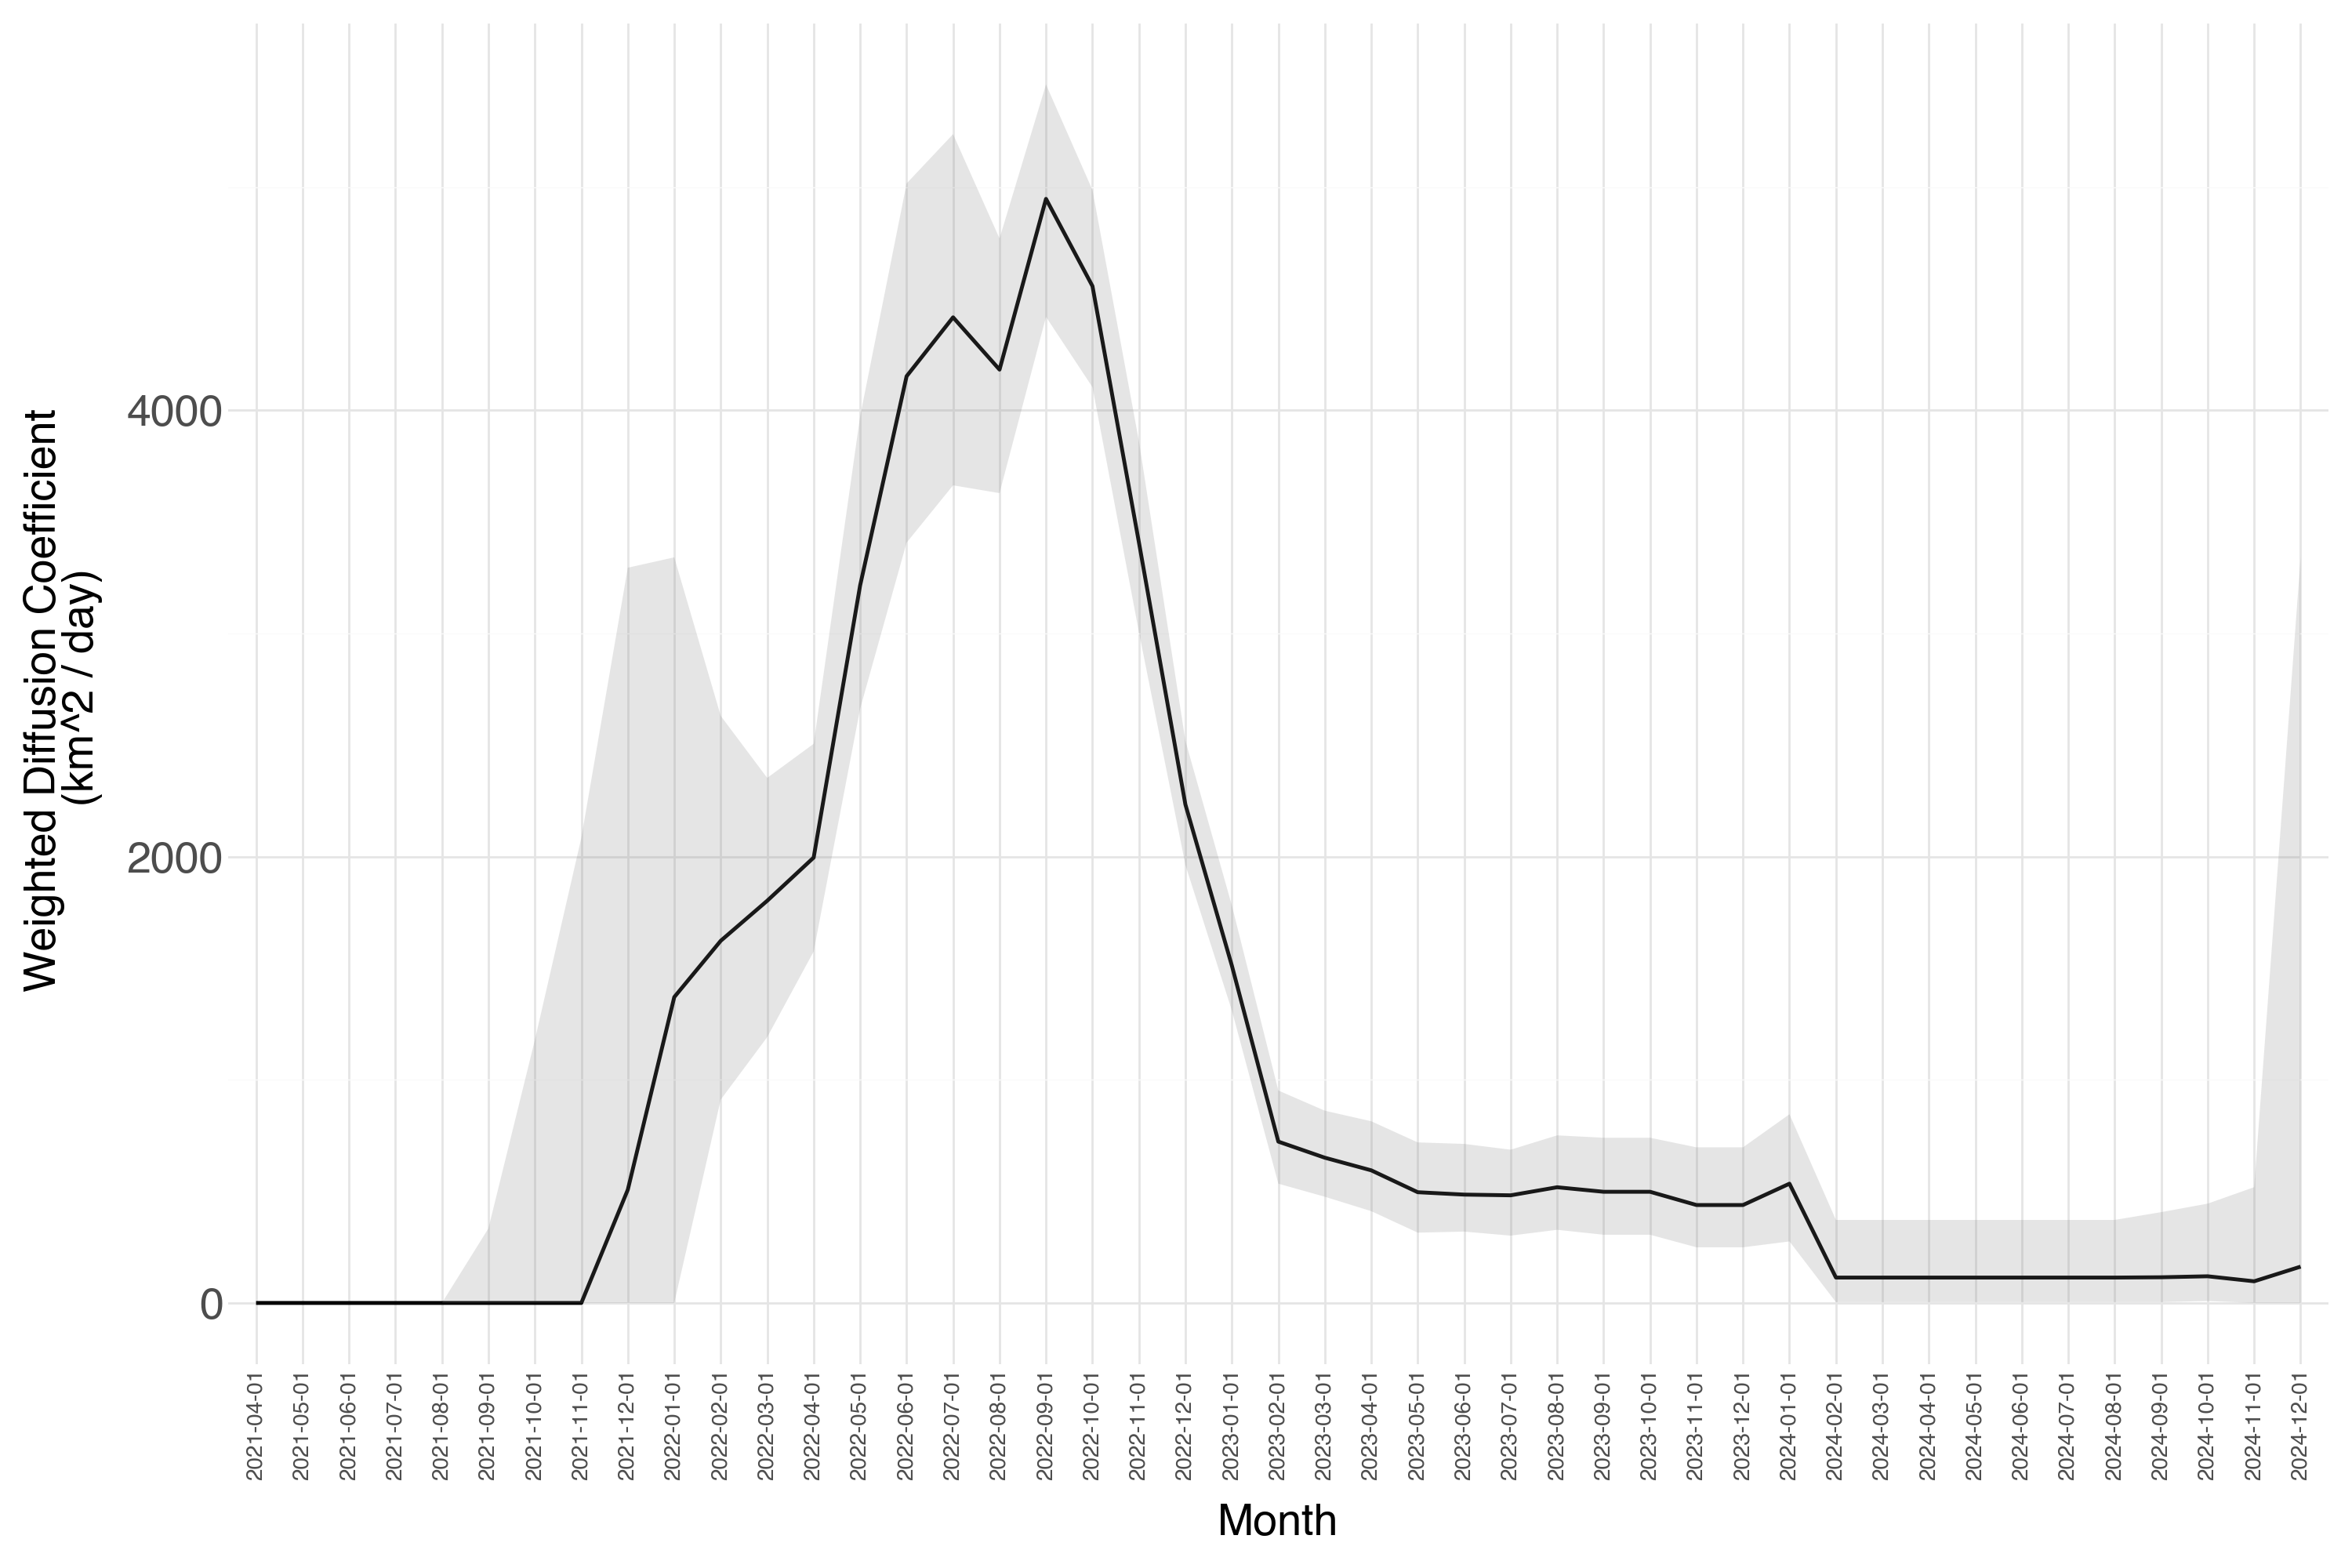

In [36]:
monthly_wdc_plt = (
    ggplot(hdi_host_wdc, aes(x = "month", y = "median", group = 1))
    + geom_line(size = 1, color = "black")
    + geom_ribbon(aes(x = "month", ymin = "lower", ymax = "upper"), fill = "grey", color = None, alpha = 0.2)
    + labs(x = "Month", y = "Weighted Diffusion Coefficient \n (km^2 / day)")
    + theme_minimal()
    + theme(figure_size = (15,10), legend_text=element_text(size=20), axis_title_x = element_text(size = 20), 
            axis_title_y = element_text(size = 20), text=element_text(size=20), axis_text_x = element_text(size = 10, rotation = 90))
)

monthly_wdc_plt.show()

In [100]:
# I am not using quantiles anymore, so this code is deprecated, but I'm keeping it around
# Make quantiles so you can plot

# monthly_wdc_newindex = result.set_index(["Month", "Continent"])
# # print(monthly_wdc_newindex)

# monthly_wdc_quantiles = monthly_wdc_newindex.quantile([0.025, 0.5, 0.975], axis = 1).T
# monthly_wdc_quantiles.columns = ["lower","median", "upper"]
# monthly_wdc_quantiles = monthly_wdc_quantiles.sort_index()

# monthly_wdc_quantiles = monthly_wdc_quantiles.reset_index()

In [9]:
# Alternate Wavefront plot
# Distribution of how far each introduction has traveled from the root
# Density on the y-axis
# Distance from the root of the introduction on the x-axis

In [36]:
def extract_subtrees(tree, traitName, dictionary):
    
    # tree_strings = defaultdict(list)
    subtype_trees = defaultdict(list)
    region_transitions = Counter()
    continent_transitions = Counter()

    for t in tree.Objects:  # Iterate over branches
        k = t  # branch
        kp = t.parent  # branch's parent

        # Get current node's and its parent's trait states
        kloc = k.traits.get(traitName, 'ancestor')
        kploc = kp.traits.get(traitName, 'ancestor')
        kc = kloc  # Current branch trait value
        kpc = kploc  # Parent branch trait value

        # # Debug: print current and parent trait states
        # print(f"Node: {k} - Trait: {kc} | Parent: {kp} - Trait: {kpc}")
        # # Node: <baltic.baltic.node object at 0x110ae8850> - Trait: europe | Parent: <baltic.baltic.node object at 0x1326a9ad0> - Trait: ancestor

        # I only want to expand subtrees by introductions into North America
        kcont = dictionary[k.traits.get(traitName, 'ancestor')] # Current branch continent
        kpcont = dictionary[kp.traits.get(traitName, 'ancestor')] # Parent branch continent
        # print(f"Node: {k} - Trait: {kcont} | Parent: {kp} - Trait: {kpcont}")
        
        # Count transitions
        # if kpc != kc:
        #     region_transitions[(kpc, kc)] += 1
            # print(f"Transition detected: {kpc} -> {kc}")

        # if kpcont != kcont:
        #     continent_transitions[(kpc, kc)] += 1

        # If continents do not match, extract subtree
        if kcont != kpcont:
            # traverse_condition = lambda w: w.traits.get(traitName, 'ancestor') == kc
            traverse_condition = lambda w: dictionary[w.traits.get(traitName, 'ancestor')] == kcont
            subtree = tree.subtree(k, traverse_condition=traverse_condition)
            
            if subtree:
                # print(f"Subtree extracted for transition: {kpc} -> {kc}")
                subtree.traverse_tree()  
                subtree.sortBranches()
                # tree_strings[kc].append(subtree.toString())
                subtype_trees[kcont].append((kpcont, subtree))
            else:
                print(f"Subtree extraction failed for {kpcont} -> {kcont}")

    # # Debug: Print final structures
    # print(f"Tree Strings: {dict(tree_strings)}")
    # print(f"Subtype Trees: {dict(subtype_trees)}")
    # print(f"Transitions: {dict(transitions)}")

    return subtype_trees #, dict(region_transitions), dict(continent_transitions)

In [27]:
def subtree_to_dataframe_with_origin(subtype_trees, traitName, most_recent_date, dictionary):
    # List to hold all subtree data
    all_subtree_data = []

    # Iterate over each subtype and its associated subtrees
    for subtype, subtree_list in subtype_trees.items():
        for i, (origin, subtree) in enumerate(subtree_list):
            
            # if "ancestor" in origin: # This subtree does not have an root with traits
            #     ances_origin = min(subtree.root.children, key=lambda child: child.absoluteTime) # ChatGPT helped me adjust my code to define the child of the origin with the minimnum absoluteTime
            #     origin_date = ances_origin.absoluteTime
            #     origin_lat = ances_origin.traits.get("location")[0]
            #     origin_long = ances_origin.traits.get("location")[1] 
            #     origin_cont = dictionary[ances_origin.traits.get("region")]
            # else:
            #     # Extract the origin date, assuming it's the root's absoluteTime minus its length
            #     origin_date = subtree.root.absoluteTime # - subtree.root.length
            #     # origin_date = subtree.root.date
            #     origin_lat = subtree.root.traits.get("location")[0]
            #     origin_long = subtree.root.traits.get("location")[1]
            #     origin_cont = dictionary[subtree.root.traits.get("region")]

            ori = min(subtree.root.children, key=lambda child: child.absoluteTime) # ChatGPT helped me adjust my code to define the child of the origin with the minimnum absoluteTime
            ori_date = ori.absoluteTime
            ori_lat = ori.traits.get("location")[0]
            ori_long = ori.traits.get("location")[1] 
            ori_cont = dictionary[ori.traits.get("region")]
            
            # Iterate through nodes in the subtree
            for node in subtree.Objects:
                # if node != subtree.root: # I don't want to include the root as a node because it is technically an ancestor, not in the tree
                if node != subtree.root and node != ori:
                    # Collect relevant information from each node
                    node_info = {
                        'branchType': node.branchType,  # 'leaf' or 'internal'
                        'date': node.absoluteTime,
                        # 'date': node.date,
                        'length': node.length,
                        'origin': origin,  # Include the origin trait
                        'origin_date': ori_date,  # Add the origin date here
                        'origin_latitude': ori_lat,
                        "origin_longitude": ori_long,
                        'origin_continent': ori_cont,
                        'subtree_name': f"{subtype}_{i}",  # Unique name for the subtree
                        # 'traits': node.traits, # This is a dictionary; we can expand it later if needed
                        'node_latitude':node.traits.get("location")[0],
                        'node_longitude': node.traits.get("location")[1],
                        'region': node.traits.get("region")
                    }
                    
                    # Expand the traits dictionary into individual columns
                    # for trait, value in node.traits.items():
                    #     node_info[trait] = value  # Each trait becomes its own column
    
                    # Add this node's information to the list
                    all_subtree_data.append(node_info)

            # Convert the list of dictionaries into a DataFrame
            df = pd.DataFrame(all_subtree_data)
            
            for idx, row in df.iterrows(): # This, again, is built to remove tree dataframes if some latitude is greater than 90
                oriLat = row["origin_latitude"]
                nodeLat = row["node_latitude"]
                if oriLat > 90:
                    return
                elif nodeLat > 90:
                    return
                else: 
                    pass
    
            df["dist_origin"] = df.apply(lambda row: great_circle((row["origin_latitude"], row["origin_longitude"]),(row["node_latitude"], row["node_longitude"])).kilometers,axis=1) # NOT SURE IF THIS IS CALC RIGHT
            df["continent"] = df["region"].map(dictionary)

    # Drop the node_attrs column if it exists (assuming it may not be needed)
    # if 'node_attrs' in df.columns:
        # df.drop(columns=['node_attrs', 'traits'], inplace=True)

    return df

In [153]:
def subtree_to_dataframe_with_origin(subtype_trees, traitName, most_recent_date, dictionary):

    count = 0

    all_subtree_data = []
    
    for subtype, subtree_list in subtype_trees.items():
        
        for i, (origin, subtree) in enumerate(subtree_list):
            if len(subtree.getExternal()) == 1: # If the subtree is just a single leaf (if the length of the subtree is just one leaf)
                origin = subtree.Objects[1]
                node = subtree.Objects[1]
                node_info = {
                            "subtree_name": f"{subtype}_{i}",
                            "origin_continent": dictionary[origin.traits.get("region")],
                            "origin_lat": origin.traits.get("location")[0],
                            "origin_long": origin.traits.get("location")[1],
                            "node_continent": dictionary[node.traits.get("region")],
                            "node_lat": node.traits.get("location")[0],
                            "node_long": node.traits.get("location")[1]
                        }
                all_subtree_data.append(node_info)
            else: # If the subtree is more than just one leaf
                origin = min(subtree.root.children, key=lambda child: child.absoluteTime) # ChatGPT helped me adjust my code to define the child of the origin with the minimnum absoluteTime
                for k in subtree.Objects:
                    if k != subtree.root and k != origin:
                        node_info = {
                            "subtree_name":f"{subtype}_{i}",
                            "origin_continent": dictionary[origin.traits.get("region")],
                            "origin_lat": origin.traits.get("location")[0],
                            "origin_long": origin.traits.get("location")[1],
                            "node_continent": dictionary[k.traits.get("region")],
                            "node_lat": k.traits.get("location")[0],
                            "node_long": k.traits.get("location")[1]
                        }
                        all_subtree_data.append(node_info)
        
    df = pd.DataFrame(all_subtree_data)

    for idx, row in df.iterrows(): # This, again, is built to remove tree dataframes if some latitude is greater than 90
        oriLat = row["origin_lat"]
        nodeLat = row["node_lat"]
        if oriLat > 90:
            return
        elif nodeLat > 90:
            return
        else: 
            pass
    
    df["dist_origin"] = df.apply(lambda row: great_circle((row["origin_lat"], row["origin_long"]),(row["node_lat"], row["node_long"])).kilometers,axis=1)
    return(df) 

In [162]:
def calculate_distfromintro(df):

    dist_from_origin = {}

    for subtree, mini_df in df.groupby("subtree_name"):
        # print(len(mini_df))
        # mini_df = mini_df.sort_values("date")
        # mini_df["cummax_dist_origin"] = mini_df["dist_origin"].cummax() # Calculate the cumulative maximum distance from origin over time
        # max_dist = max(mini_df["cummax_dist_origin"])
        max_dist = max(mini_df["dist_origin"])
        if mini_df["node_continent"].nunique() == 1:
            continent = mini_df["node_continent"].iloc[0]
        else:
            print("more than one continent", set(mini_df["node_continent"]))
            
        dist_from_origin[subtree] = {"continent": continent, "distance":max_dist} # Save to a list

    dist_from_origin_df = pd.DataFrame(dist_from_origin).T
    dist_from_origin_df["distance"] = dist_from_origin_df["distance"].astype(int)
    
    return(dist_from_origin_df)

In [163]:
# Function: Generate a dictionary of metadata dataframes from a distribution

def distribution_dist_dict(tree_path, numtrees, burnin_percent, temp_tree, dictionary, traitName, MRSD):

    treeCounter = 0
    burnin = int(numtrees * burnin_percent)
    dist_list = []

    # trees = bt.loadNexus(tree_path)
    with open(tree_path) as infile:
        for line in infile:

            # write an empty tree to read file; this will get filled in as a new nexus file for each tree in the posterior
            with open(temp_tree, "w") as outfile:
                outfile.write("")

            if 'tree STATE_' in line:
                treeCounter += 1
                if treeCounter > burnin:
                # if treeCounter < 5:
                    with open(temp_tree, "a") as outfile:
                        outfile.write(lines_to_write)
                        outfile.write(line)
                    tree = bt.loadNexus(temp_tree, absoluteTime=True, verbose=False)

                    subtype_trees = extract_subtrees(tree, traitName, continent_dict) # Extract subtype trees

                    tree_df = subtree_to_dataframe_with_origin(subtype_trees, traitName, MRSD, dictionary) # Turn this into a dataframe

                    if tree_df is None: # Trying to avoid situations where I skip a tree for some reason and it adds None to the dictionary
                        pass
                    else:
                        tree_dist = calculate_distfromintro(tree_df)
                        # print(len(tree_dist))
                        tree_dist["tree"] = f"tree{treeCounter}"
                        
                        dist_list.append(tree_dist)

        # print(dist_list)
        distribution = pd.concat(dist_list)

    return(distribution)

In [164]:
# tree_path = "../../H5N5-seabird-phylo/SERAPHIM/A6_concat-genome_traits_2026-03-10_901combined.trees"
# tree_path = "../../H5N5-seabird-phylo/BEAST/cont-phyl_dta/results/2026-07-09_A6_concat_genome_traits/A6_concat-gen_traits_2026-07-09_901combined.trees"
tree_path = "../../H5N5-seabird-phylo/BEAST/cont-phyl_dta/results/2026-08-04_A6_concat_genome_traits_TEST/A6_concat-gen_traits_2026-08-04_884combined.trees"

temp_tree = tree_path.replace(".trees",".tempcomm.history.tree")
lines_to_write = get_taxa_lines(tree_path)

In [165]:
# MRSD = 2025.8575342465754
MRSD = 2026.0520547945205

distribution_dist_df = distribution_dist_dict(tree_path, 884, 0.0, temp_tree, continent_dict, "region", MRSD)

Subtree extraction failed for ancestor -> north-america
Subtree extraction failed for ancestor -> north-america
Subtree extraction failed for ancestor -> north-america
Subtree extraction failed for ancestor -> north-america
Subtree extraction failed for ancestor -> north-america
Subtree extraction failed for ancestor -> north-america


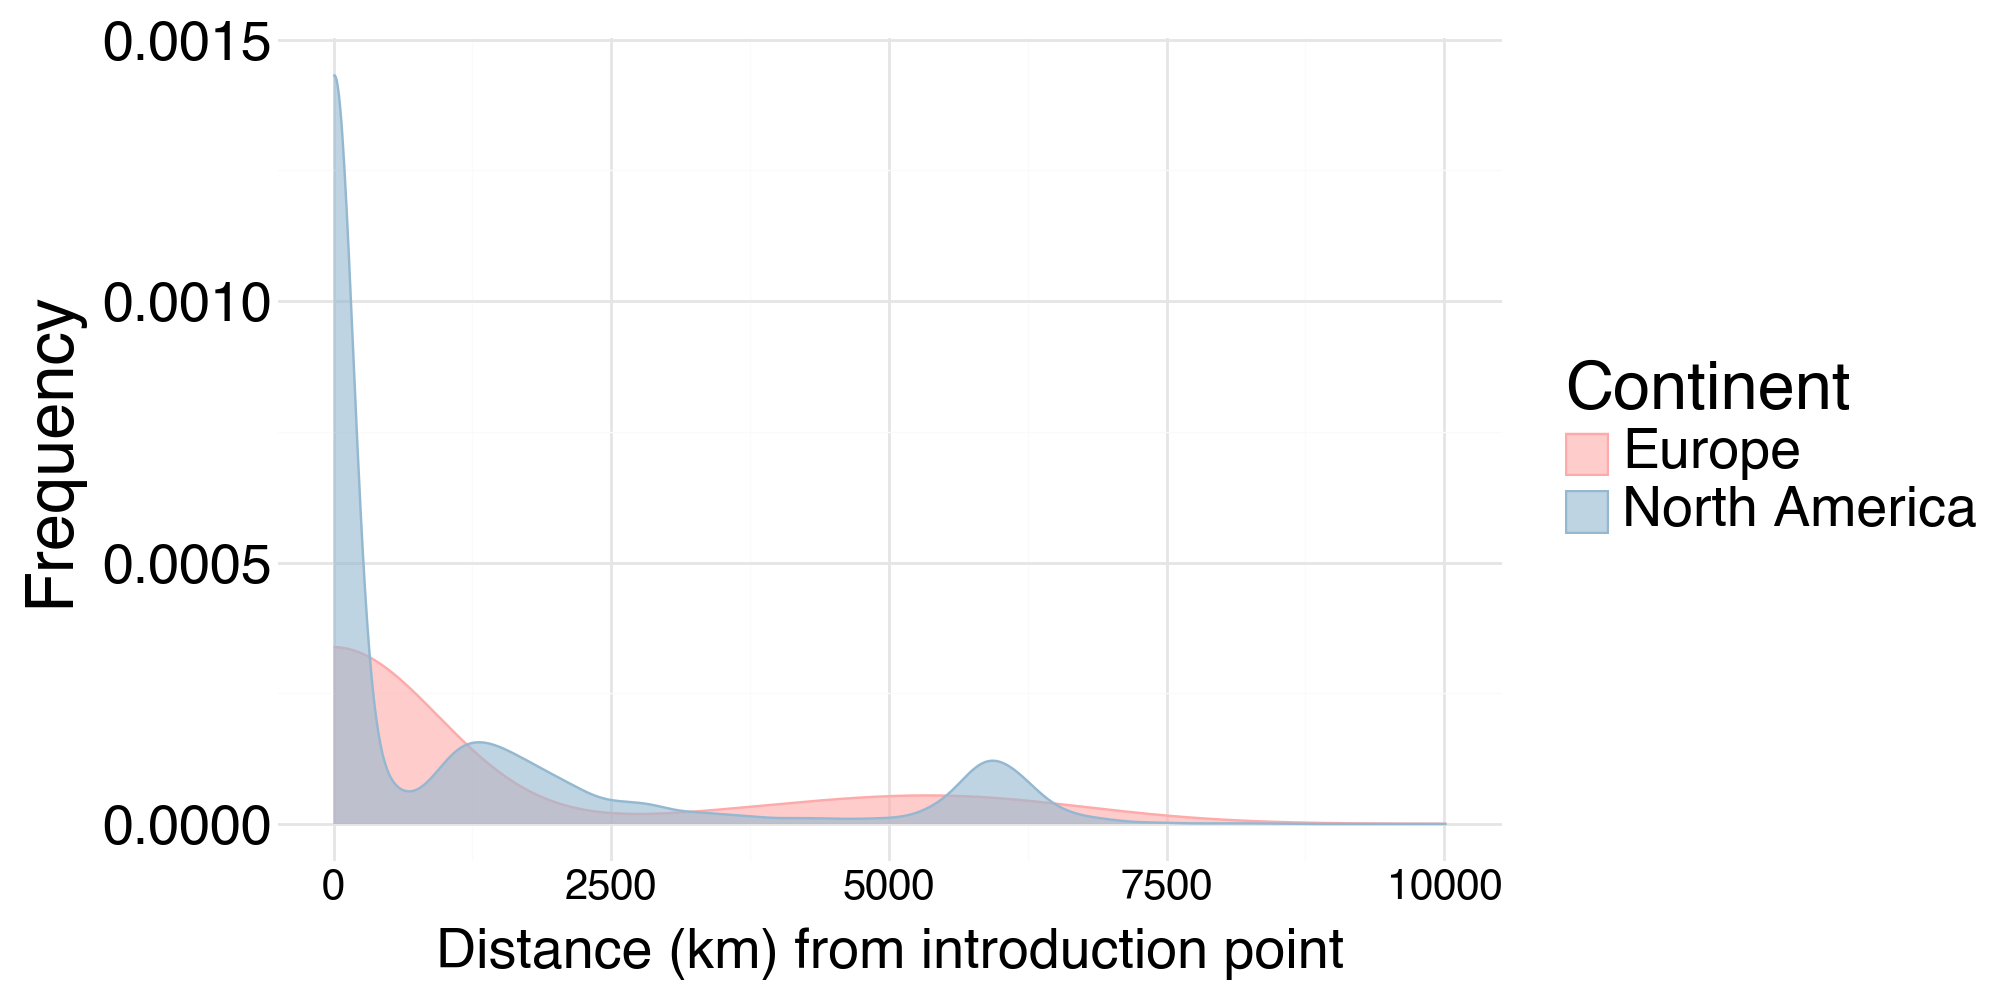

In [168]:
distfromintro_plot = (
    ggplot(distribution_dist_df[~(distribution_dist_df["continent"] == "asia")], aes(x = "distance", color = "continent", fill = "continent"))
    + geom_density(alpha = 0.6)
    + labs(x = "Distance (km) from introduction point", y = "Frequency", fill = "Continent", color = "Continent")
    + scale_fill_manual(values = continent_colors, labels = {"asia":"Asia", "europe":"Europe", "north-america":"North America"})
    + scale_color_manual(values = continent_colors, labels = {"asia":"Asia", "europe":"Europe", "north-america":"North America"})
    + theme_minimal()
    + theme(figure_size = (10,5), legend_title = element_text(size = 24), legend_text=element_text(size=20), 
            axis_title_x = element_text(size = 20), axis_text_x = element_text(size = 15, color = "black"),
            axis_title_y = element_text(size = 24), axis_text_y = element_text(size = 20, color = "black"))
)

distfromintro_plot.show()

In [169]:
distfromintro_plot.save("../../H5N5-seabird-phylo/SERAPHIM/plots/dist-from-intro_across-posterior.png", format = "png", dpi = 750)

/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 5 in image.
/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../../H5N5-seabird-phylo/SERAPHIM/plots/dist-from-intro_across-posterior.png


In [ ]:
# Ideal wavefront plot
# X axis is rolling weekly timebins
# Y axis is max dist per rolling week
# Median max distance per continent
# upper/lower max distance per continent

In [ ]:
# Function: turn float date to datetime
def decimal_year_to_datetime(decimal_year): # This function came from ChatGPT because I'm bad with datetime
    year = int(decimal_year)
    remainder = decimal_year - year

    start = datetime(year, 1, 1)
    end = datetime(year + 1, 1, 1)

    seconds_in_year = (end - start).total_seconds()
    dt = start + timedelta(seconds=remainder * seconds_in_year)

    return(dt)

In [140]:
# Function: Calculates weighted diffusion coefficient from either the posterior distirbution or an MCC tree
def calculate_spatialwavefront(metadata):

    if isinstance(metadata, dict): # If you are calculating from a dictionary of dataframes
        posterior_wavefront = {}
        df_count = 1
        
        for df in metadata.values():
            
            posterior_wavefront[df_count] = {}

            df["startYear2"] = df["startYear"].apply(decimal_year_to_datetime)

            df_wavefront_rows = [] # establish somewhere to save the columns for each continent

            for (startContinent, endContinent), df_cont in df.groupby(["startContinent", "endContinent"]): # Group by continent
                
                if startContinent == endContinent:
                    df_cont = df_cont.sort_values("startYear2")
                    df_cont["max_dist"] = df_cont["dist_origin"].cummax() # Calculate the cumulative maximum distance from origin over time
                    df_wavefront_rows.append(df_cont) # Save to a list

                else:
                    pass

            df_wavefront = pd.concat(df_wavefront_rows)

            posterior_wavefront[df_count] = df_wavefront

            df_count += 1

        posterior_wavefront_df = pd.concat(posterior_wavefront, names = ["treeNumber"]).reset_index() # Concatenate all posterior dataframes with treeNumber in a column
        
        needed_columns = ["treeNumber", "startYear", "endYear", "startYear2", "startContinent", "endContinent", "dist_origin", "max_dist"]
        posterior_wavefront_df_filtered = posterior_wavefront_df.loc[0:, needed_columns] # Filter to just a few columns for ease
            
        return(posterior_wavefront_df_filtered)

    if isinstance(metadata, pd.DataFrame): # if you are calculating from just one dataframe
        mcc_wavefront_rows = []

        metadata["startYear2"] = metadata["startYear"].apply(decimal_year_to_datetime)

        for (startHost, endHost), metadata_host in metadata.groupby(["startHost", "endHost"]): # Group by host (or continent, or whatever)
            
            if startHost == endHost: # Only run this calculation on lines that are NOT transitioning from one host to another
                metadata_host = metadata_host.sort_values("startYear2") # Order each host group in ascending time order
                metadata_host["max_dist"] = metadata_host["dist_origin"].cummax() # Calculate the cumulative maximum distance from origin over time
                mcc_wavefront_rows.append(metadata_host) # Save to a list
                
            else:
                pass

        # needed_columns = ["startHost", "endHost", "startContinent", "endContinent", "startYear2", "dist_origin", "max_dist"]
        mcc_wavefront_df = pd.concat(mcc_wavefront_rows) # concatenate all hosts
        
        return(mcc_wavefront_df)

    else:
        print("Metadata of unknown type")

In [142]:
post_wavefront_df = calculate_spatialwavefront(metadata_dict)
# mcc_wavefront_df = calculate_spatialwavefront(mcc_metadata)

In [ ]:
post_wavefront_df["month_bin"] = post_wavefront_df["startYear2"].dt.to_period("M")
median_wavefront = post_wavefront_df.groupby(["month_bin", "startContinent"])["max_dist"].median().reset_index()
median_wavefront["month_bin"] = median_wavefront["month_bin"].dt.to_timestamp()
print(median_wavefront)

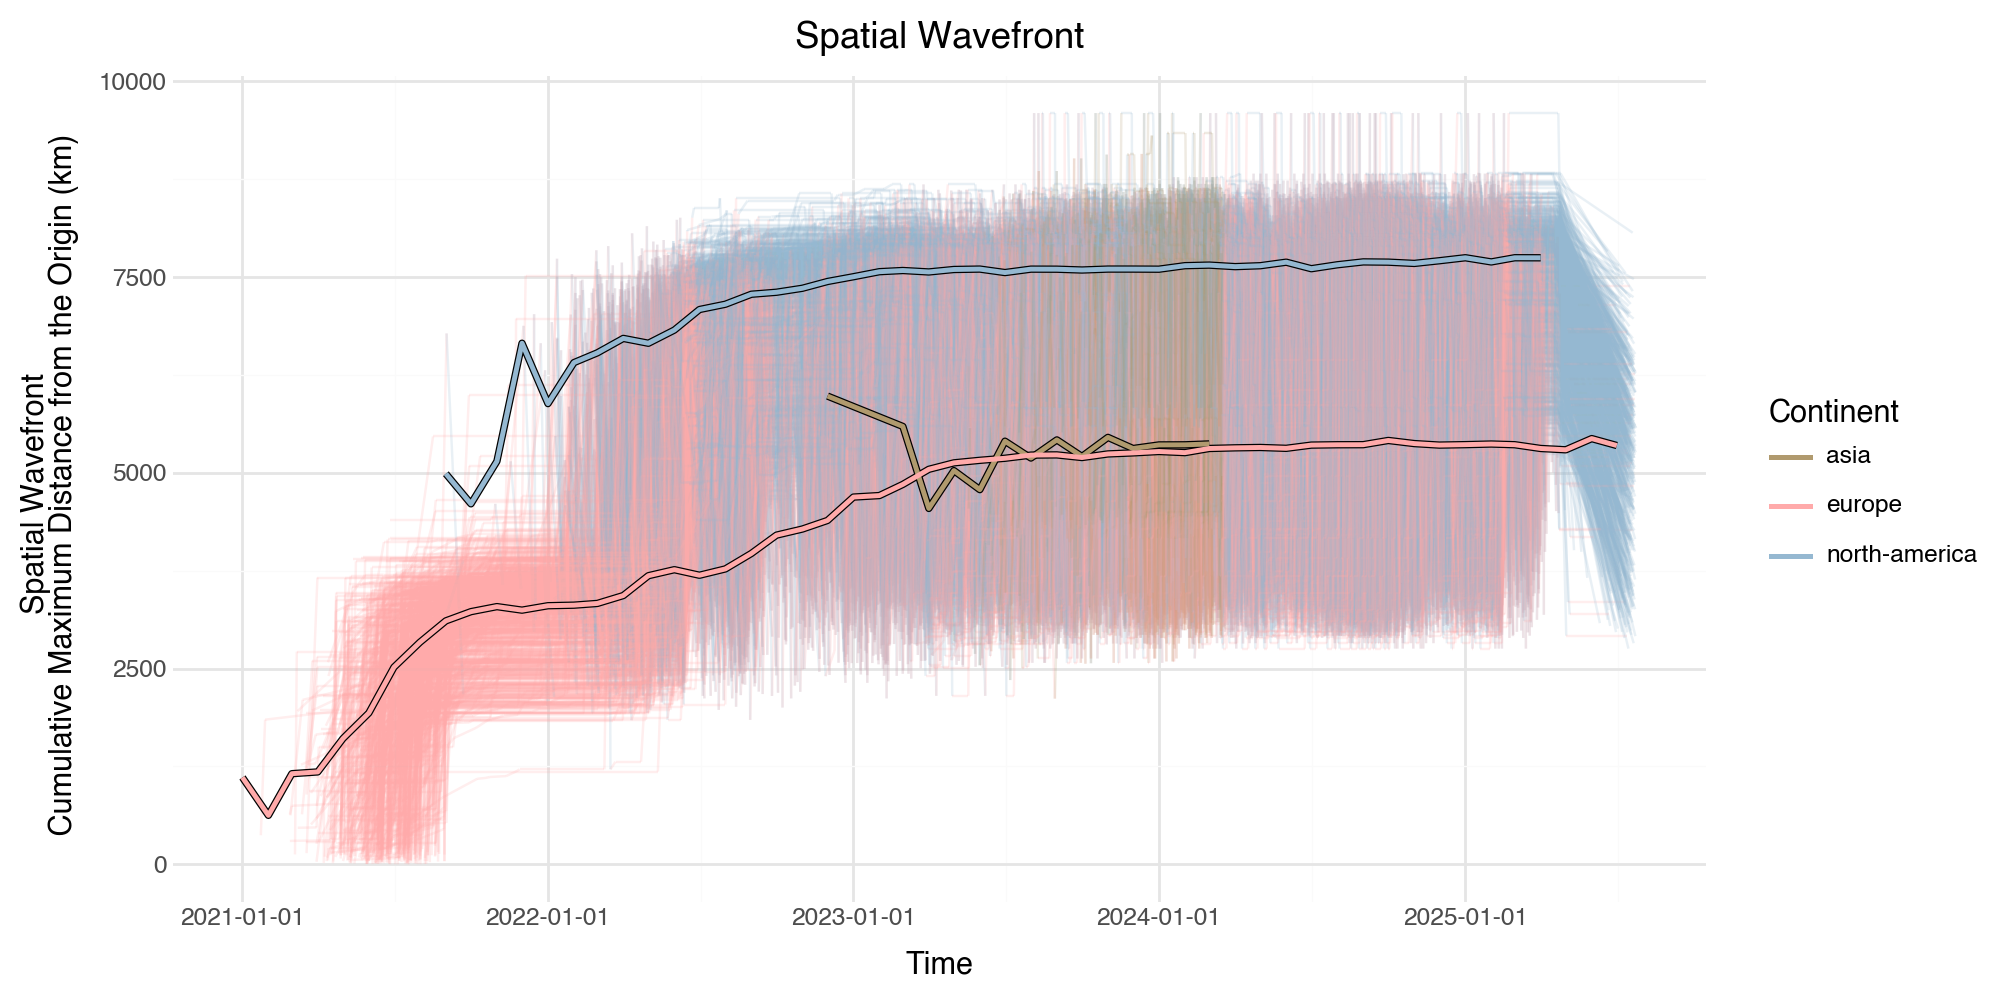

In [170]:
wavefront_plt = (
    ggplot()
    + geom_line(post_wavefront_df, aes(x = "startYear2", y = "max_dist", group = "treeNumber", color = "startContinent"), alpha = 0.2)
    + geom_line(median_wavefront, aes(x = "month_bin", y = "max_dist", group = "startContinent"), size = 1.5, color = "black")
    + geom_line(median_wavefront, aes(x = "month_bin", y = "max_dist", color = "startContinent"), size = 1)
    + scale_color_manual(continent_colors)
    + labs(x = "Time", y = "Spatial Wavefront \n Cumulative Maximum Distance from the Origin (km)", color = "Continent", title = "Spatial Wavefront")
    + theme_minimal()
    + theme(figure_size = (10, 5))
)

wavefront_plt.show()

In [171]:
wavefront_plt.save("../../H5N5-mini-project/SERAPHIM/output_plots/wavefront_across_posterior.png", format = "png", dpi = 750)

/Users/claramal/miniconda3/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 5 in image.
/Users/claramal/miniconda3/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ../../H5N5-mini-project/SERAPHIM/output_plots/wavefront_across_posterior.png
